        Date     A      B      C      D
0 2025-01-01  47.0   75.0  353.0  143.0
1 2025-01-02  82.0  184.0  491.0  195.0
2 2025-01-03  92.0  186.0  462.0  183.0
3 2025-01-04  70.0  148.0  352.0  155.0
4 2025-01-05  40.0  110.0  224.0   98.0


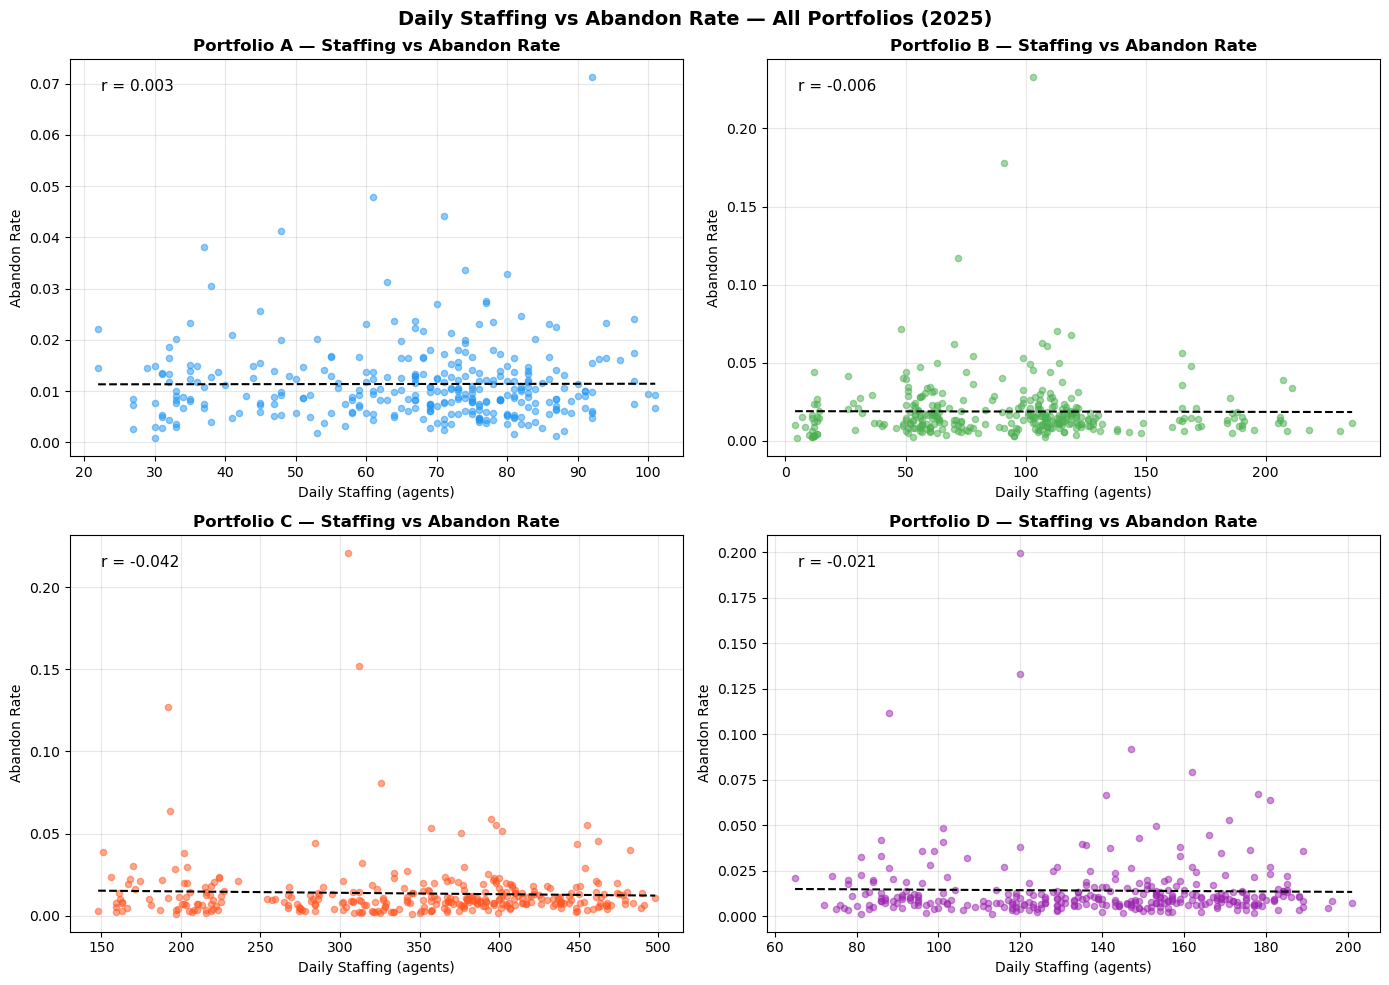

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load staffing data
df_staffing = pd.read_csv('./data/Daily Staffing.csv', index_col=0)
df_staffing.columns = ['Date', 'A', 'B', 'C', 'D']
df_staffing['Date'] = pd.to_datetime(df_staffing['Date'])
print(df_staffing.head())

# Load daily data for all 4 portfolios
portfolios = ['A', 'B', 'C', 'D']
daily_data = {}
for p in portfolios:
    d = pd.read_csv(f'./data/{p} - Daily.csv', index_col=0)
    d['Date'] = pd.to_datetime(d['Date'].str[:8], format='%m/%d/%y')
    daily_data[p] = d

# Merge staffing with abandon rate for each portfolio
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors = {'A': '#2196F3', 'B': '#4CAF50', 'C': '#FF5722', 'D': '#9C27B0'}

for i, p in enumerate(portfolios):
    # Merge on date
    merged = daily_data[p].merge(
        df_staffing[['Date', p]].rename(columns={p: 'Staffing'}),
        on='Date', how='inner'
    ).dropna(subset=['Abandon Rate', 'Staffing'])

    axes[i].scatter(
        merged['Staffing'], merged['Abandon Rate'],
        color=colors[p], alpha=0.5, s=20
    )

    # Trend line
    z = np.polyfit(merged['Staffing'], merged['Abandon Rate'], 1)
    p_line = np.poly1d(z)
    x_sorted = np.sort(merged['Staffing'])
    axes[i].plot(x_sorted, p_line(x_sorted), color='black', linewidth=1.5, linestyle='--')

    axes[i].set_title(f'Portfolio {p} — Staffing vs Abandon Rate', fontweight='bold')
    axes[i].set_xlabel('Daily Staffing (agents)')
    axes[i].set_ylabel('Abandon Rate')
    axes[i].grid(True, alpha=0.3)

    # Correlation
    corr = merged['Staffing'].corr(merged['Abandon Rate'])
    axes[i].annotate(f'r = {corr:.3f}', xy=(0.05, 0.92),
                     xycoords='axes fraction', fontsize=11, color='black')

plt.suptitle('Daily Staffing vs Abandon Rate — All Portfolios (2025)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

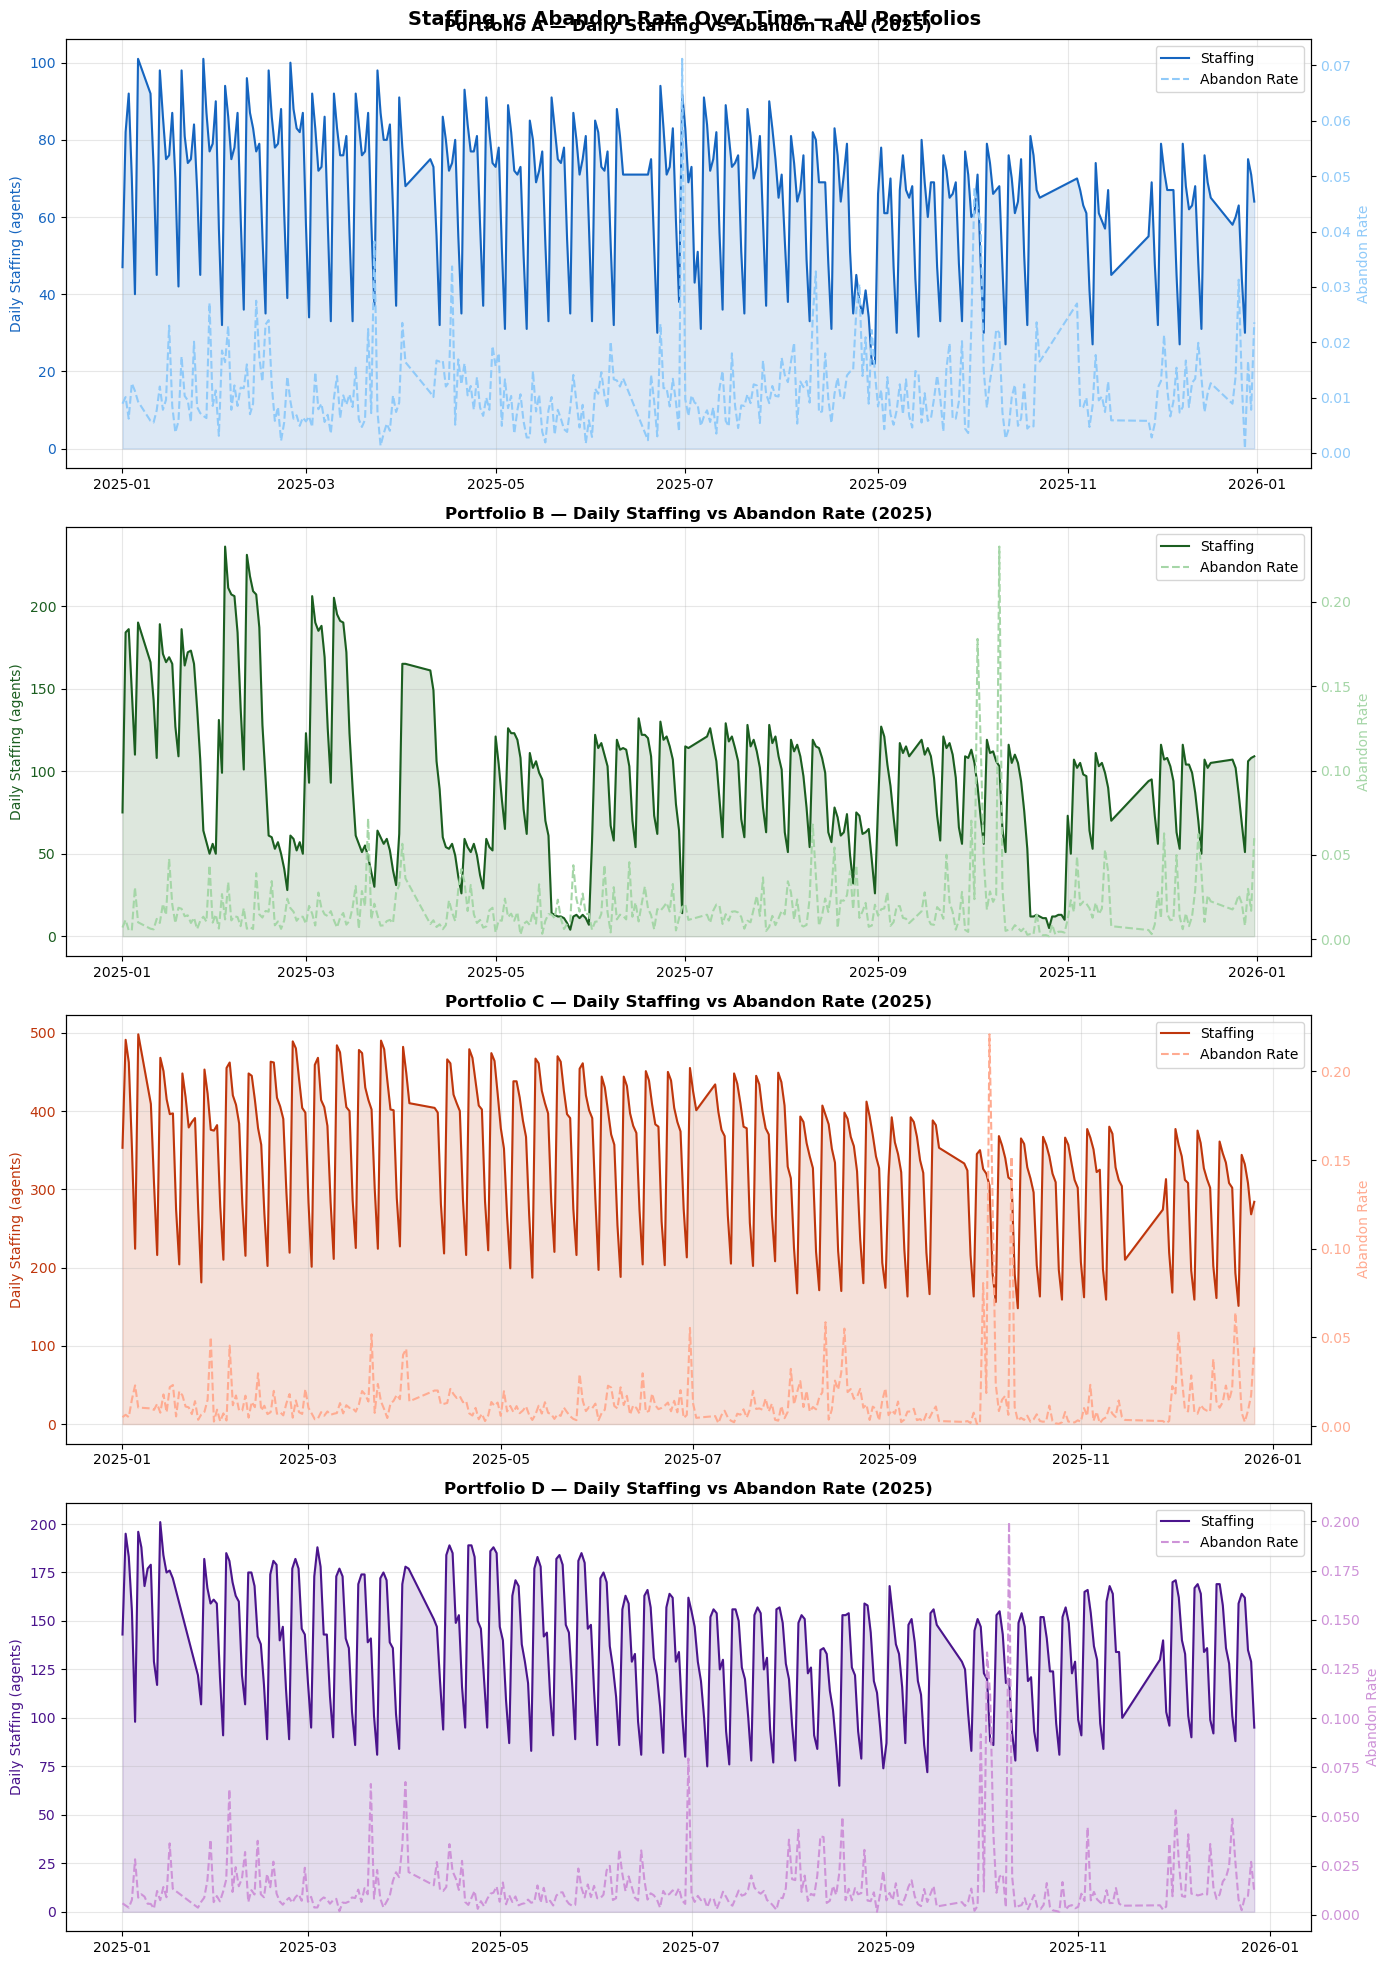

In [8]:
# Load staffing data
df_staffing = pd.read_csv('./data/Daily Staffing.csv', index_col=0)
df_staffing.columns = ['Date', 'A', 'B', 'C', 'D']
df_staffing['Date'] = pd.to_datetime(df_staffing['Date'])

# Load daily data for all 4 portfolios
portfolios = ['A', 'B', 'C', 'D']
daily_data = {}
for p in portfolios:
    d = pd.read_csv(f'./data/{p} - Daily.csv', index_col=0)
    d['Date'] = pd.to_datetime(d['Date'].str[:8], format='%m/%d/%y')
    daily_data[p] = d

# Plot staffing vs abandon rate over time (dual axis)
fig, axes = plt.subplots(4, 1, figsize=(14, 20), sharex=False)

colors_staff = {'A': '#1565C0', 'B': '#1B5E20', 'C': '#BF360C', 'D': '#4A148C'}
colors_abd   = {'A': '#90CAF9', 'B': '#A5D6A7', 'C': '#FFAB91', 'D': '#CE93D8'}

for i, p in enumerate(portfolios):
    merged = daily_data[p].merge(
        df_staffing[['Date', p]].rename(columns={p: 'Staffing'}),
        on='Date', how='inner'
    ).dropna(subset=['Abandon Rate', 'Staffing']).sort_values('Date')

    ax1 = axes[i]
    ax2 = ax1.twinx()

    ax1.plot(merged['Date'], merged['Staffing'], 
             color=colors_staff[p], linewidth=1.5, label='Staffing')
    ax1.fill_between(merged['Date'], merged['Staffing'], 
                     alpha=0.15, color=colors_staff[p])
    ax1.set_ylabel('Daily Staffing (agents)', color=colors_staff[p])
    ax1.tick_params(axis='y', labelcolor=colors_staff[p])

    ax2.plot(merged['Date'], merged['Abandon Rate'], 
             color=colors_abd[p], linewidth=1.5, linestyle='--', label='Abandon Rate')
    ax2.set_ylabel('Abandon Rate', color=colors_abd[p])
    ax2.tick_params(axis='y', labelcolor=colors_abd[p])

    ax1.set_title(f'Portfolio {p} — Daily Staffing vs Abandon Rate (2025)', fontweight='bold')
    ax1.grid(True, alpha=0.3)

    # Combined legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.suptitle('Staffing vs Abandon Rate Over Time — All Portfolios', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

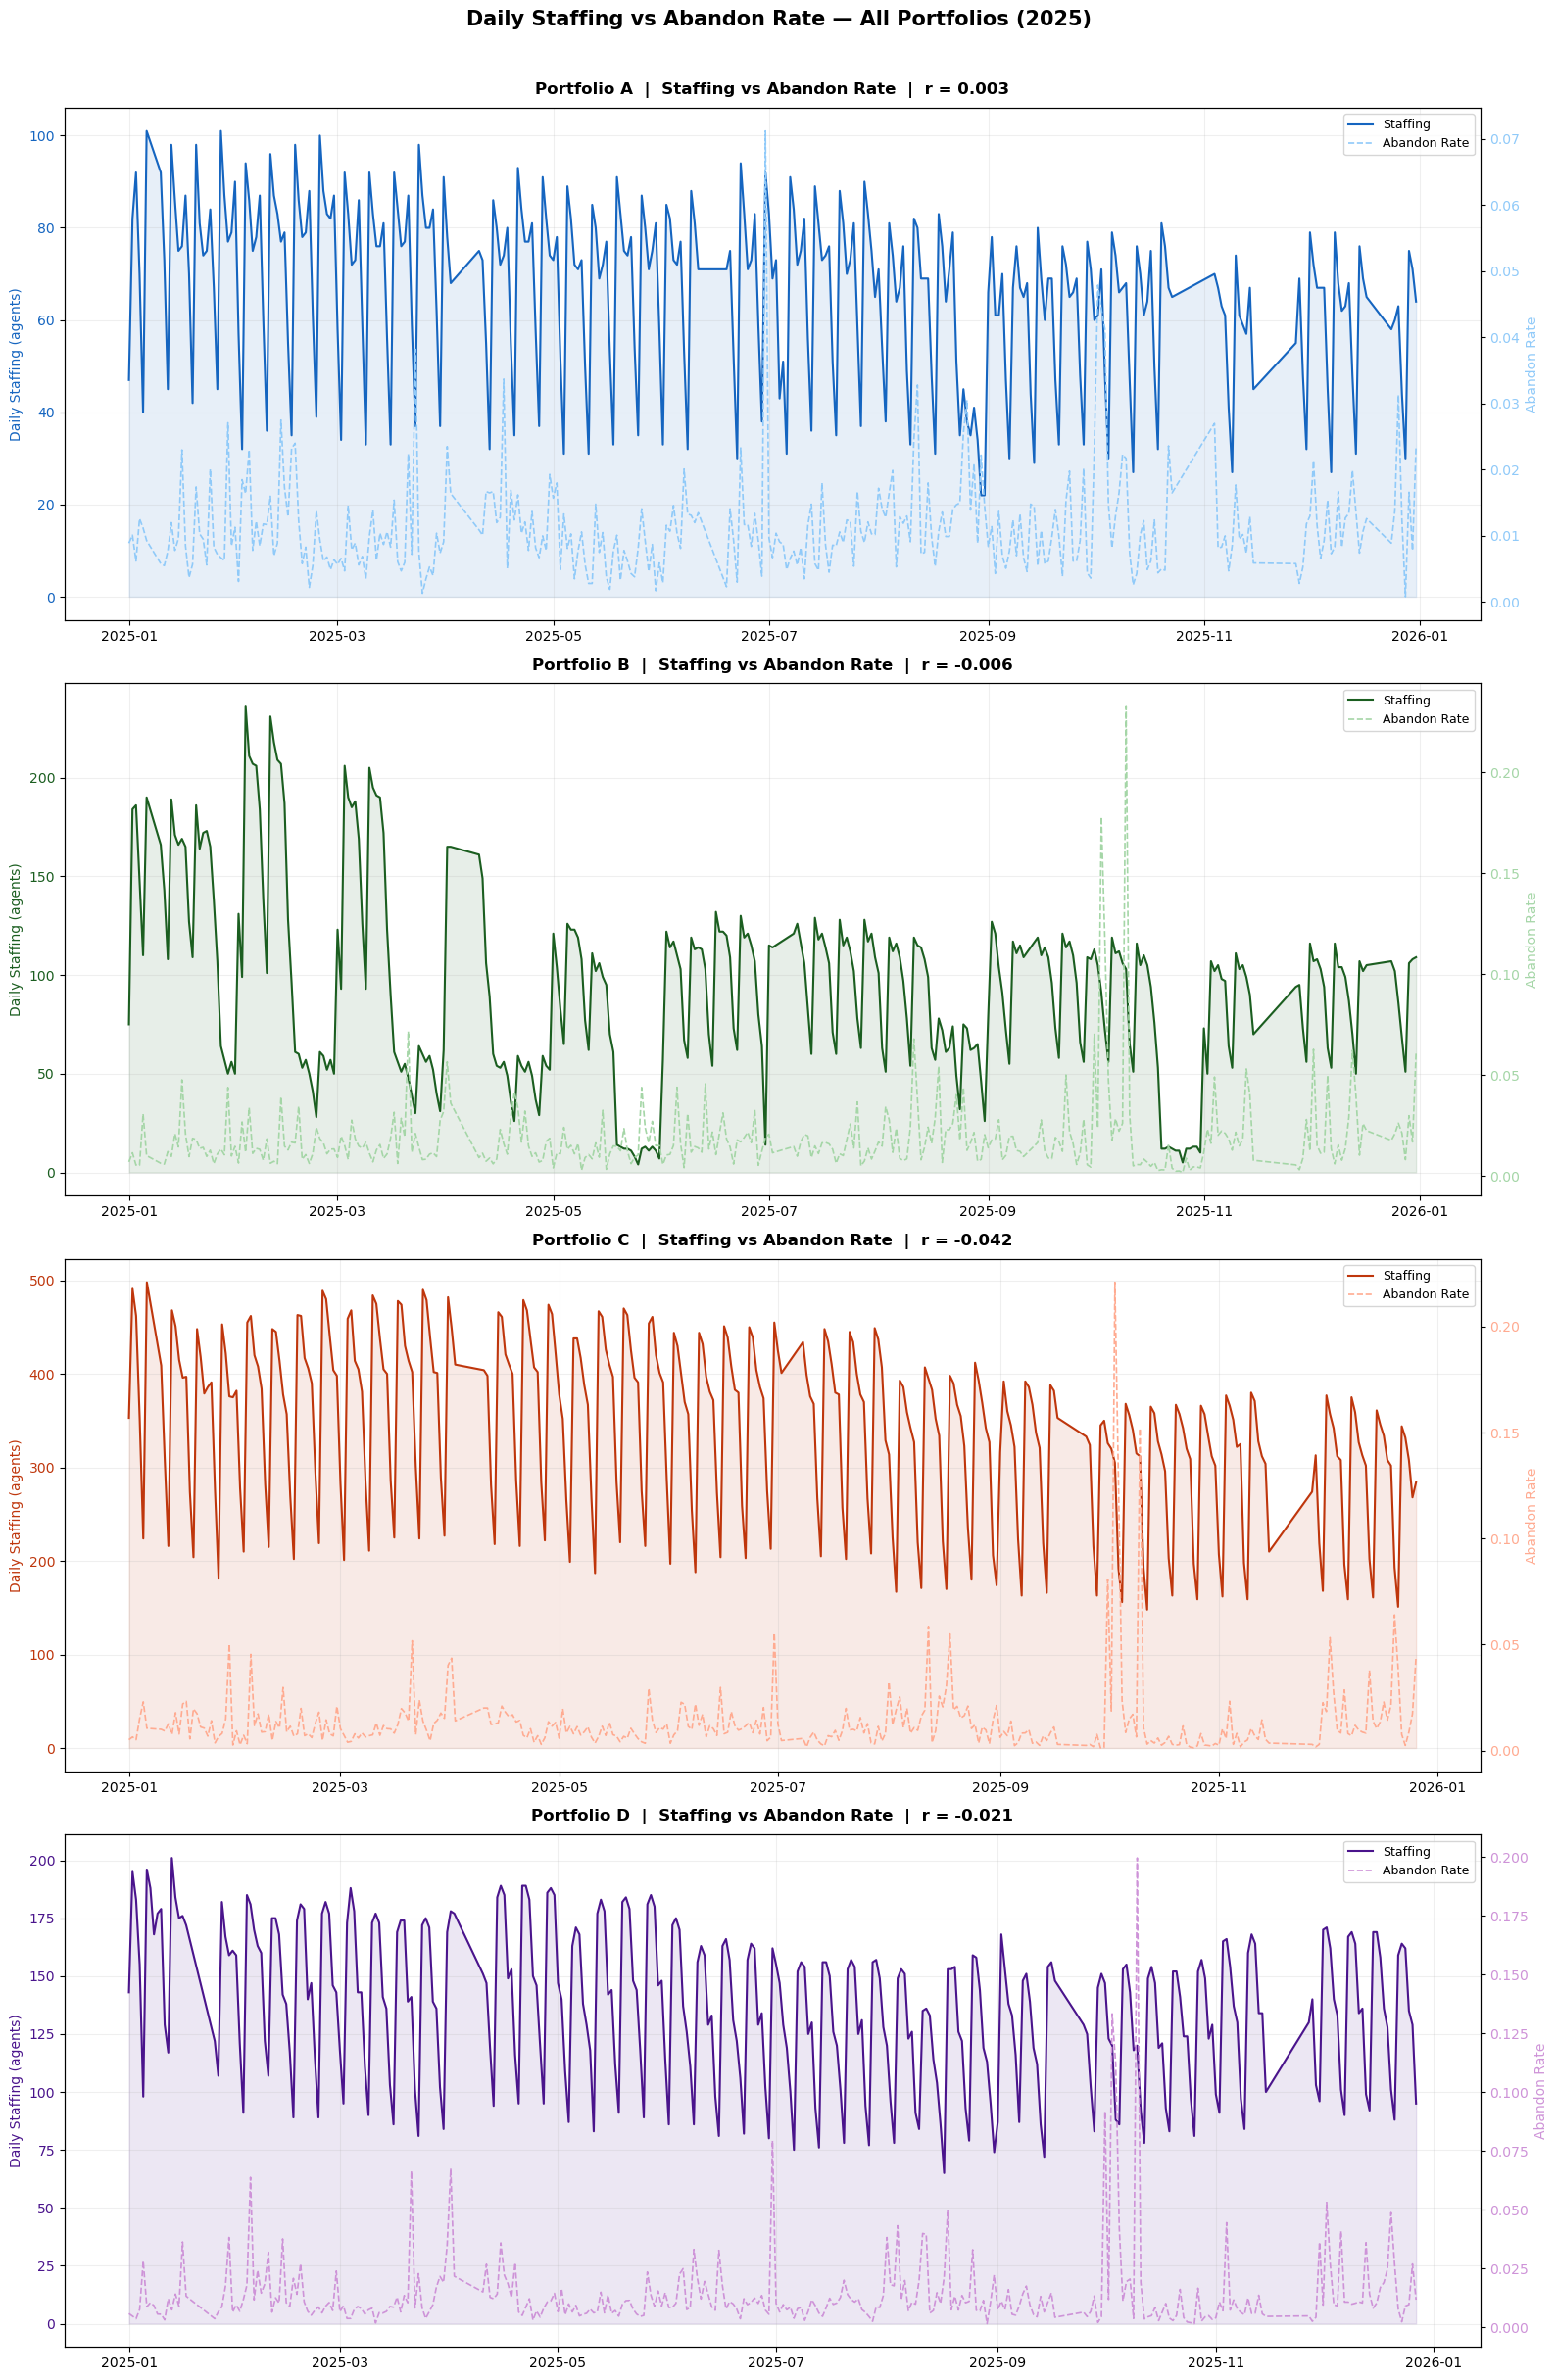

In [9]:
fig, axes = plt.subplots(4, 1, figsize=(16, 24), sharex=False)
fig.subplots_adjust(hspace=0.4)

colors_staff = {'A': '#1565C0', 'B': '#1B5E20', 'C': '#BF360C', 'D': '#4A148C'}
colors_abd   = {'A': '#90CAF9', 'B': '#A5D6A7', 'C': '#FFAB91', 'D': '#CE93D8'}

for i, p in enumerate(portfolios):
    merged = daily_data[p].merge(
        df_staffing[['Date', p]].rename(columns={p: 'Staffing'}),
        on='Date', how='inner'
    ).dropna(subset=['Abandon Rate', 'Staffing']).sort_values('Date')

    ax1 = axes[i]
    ax2 = ax1.twinx()

    ax1.plot(merged['Date'], merged['Staffing'],
             color=colors_staff[p], linewidth=1.5, label='Staffing')
    ax1.fill_between(merged['Date'], merged['Staffing'],
                     alpha=0.1, color=colors_staff[p])
    ax1.set_ylabel('Daily Staffing (agents)', color=colors_staff[p], fontsize=10)
    ax1.tick_params(axis='y', labelcolor=colors_staff[p])

    ax2.plot(merged['Date'], merged['Abandon Rate'],
             color=colors_abd[p], linewidth=1.2, linestyle='--', label='Abandon Rate')
    ax2.set_ylabel('Abandon Rate', color=colors_abd[p], fontsize=10)
    ax2.tick_params(axis='y', labelcolor=colors_abd[p])

    corr = merged['Staffing'].corr(merged['Abandon Rate'])
    ax1.set_title(f'Portfolio {p}  |  Staffing vs Abandon Rate  |  r = {corr:.3f}',
                  fontsize=12, fontweight='bold', pad=10)
    ax1.grid(True, alpha=0.2)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)

fig.suptitle('Daily Staffing vs Abandon Rate — All Portfolios (2025)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [10]:
df_daily = pd.read_csv('./data/C - Daily.csv', index_col=0)

In [12]:
df_daily['Date'] = pd.to_datetime(df_daily['Date'].str[:8], format='%m/%d/%y')
df_daily['day_of_month'] = df_daily['Date'].dt.day
df_daily['is_start_of_month'] = (df_daily['day_of_month'] <= 5).astype(int)
df_daily['is_end_of_month']   = (df_daily['day_of_month'] >= 25).astype(int)

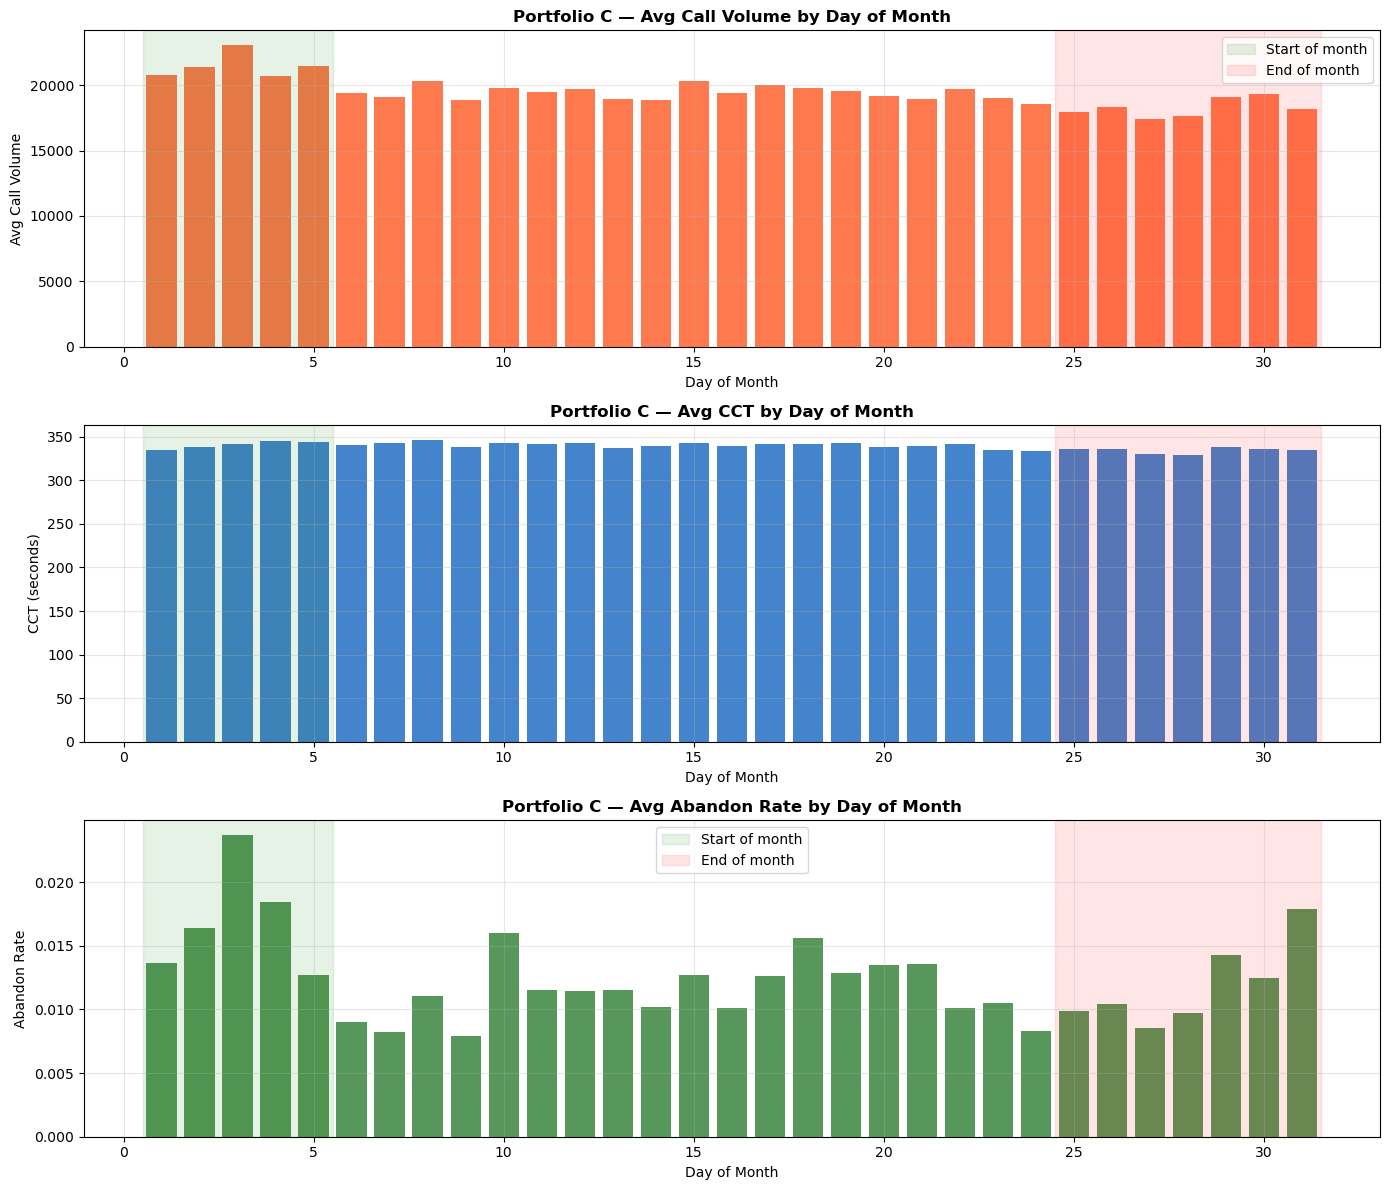

In [13]:
# Add billing cycle flags to daily data
df_daily['is_start_of_month'] = (df_daily['day_of_month'] <= 5).astype(int)
df_daily['is_end_of_month']   = (df_daily['day_of_month'] >= 25).astype(int)

# Plot average call volume by day of month to see if pattern exists
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Plot 1 - avg CV by day of month
avg_by_dom = df_daily.groupby('day_of_month')['Call Volume'].mean()
axes[0].bar(avg_by_dom.index, avg_by_dom.values, color='#FF5722', alpha=0.8)
axes[0].axvspan(0.5, 5.5, alpha=0.1, color='green', label='Start of month')
axes[0].axvspan(24.5, 31.5, alpha=0.1, color='red', label='End of month')
axes[0].set_title('Portfolio C — Avg Call Volume by Day of Month', fontweight='bold')
axes[0].set_xlabel('Day of Month')
axes[0].set_ylabel('Avg Call Volume')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2 - avg CCT by day of month
avg_cct_dom = df_daily.groupby('day_of_month')['CCT'].mean()
axes[1].bar(avg_cct_dom.index, avg_cct_dom.values, color='#1565C0', alpha=0.8)
axes[1].axvspan(0.5, 5.5, alpha=0.1, color='green')
axes[1].axvspan(24.5, 31.5, alpha=0.1, color='red')
axes[1].set_title('Portfolio C — Avg CCT by Day of Month', fontweight='bold')
axes[1].set_xlabel('Day of Month')
axes[1].set_ylabel('CCT (seconds)')
axes[1].grid(True, alpha=0.3)

# Plot 3 - avg abandon rate by day of month
avg_abd_dom = df_daily.groupby('day_of_month')['Abandon Rate'].mean()
axes[2].bar(avg_abd_dom.index, avg_abd_dom.values, color='#2E7D32', alpha=0.8)
axes[2].axvspan(0.5, 5.5, alpha=0.1, color='green', label='Start of month')
axes[2].axvspan(24.5, 31.5, alpha=0.1, color='red', label='End of month')
axes[2].set_title('Portfolio C — Avg Abandon Rate by Day of Month', fontweight='bold')
axes[2].set_xlabel('Day of Month')
axes[2].set_ylabel('Abandon Rate')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

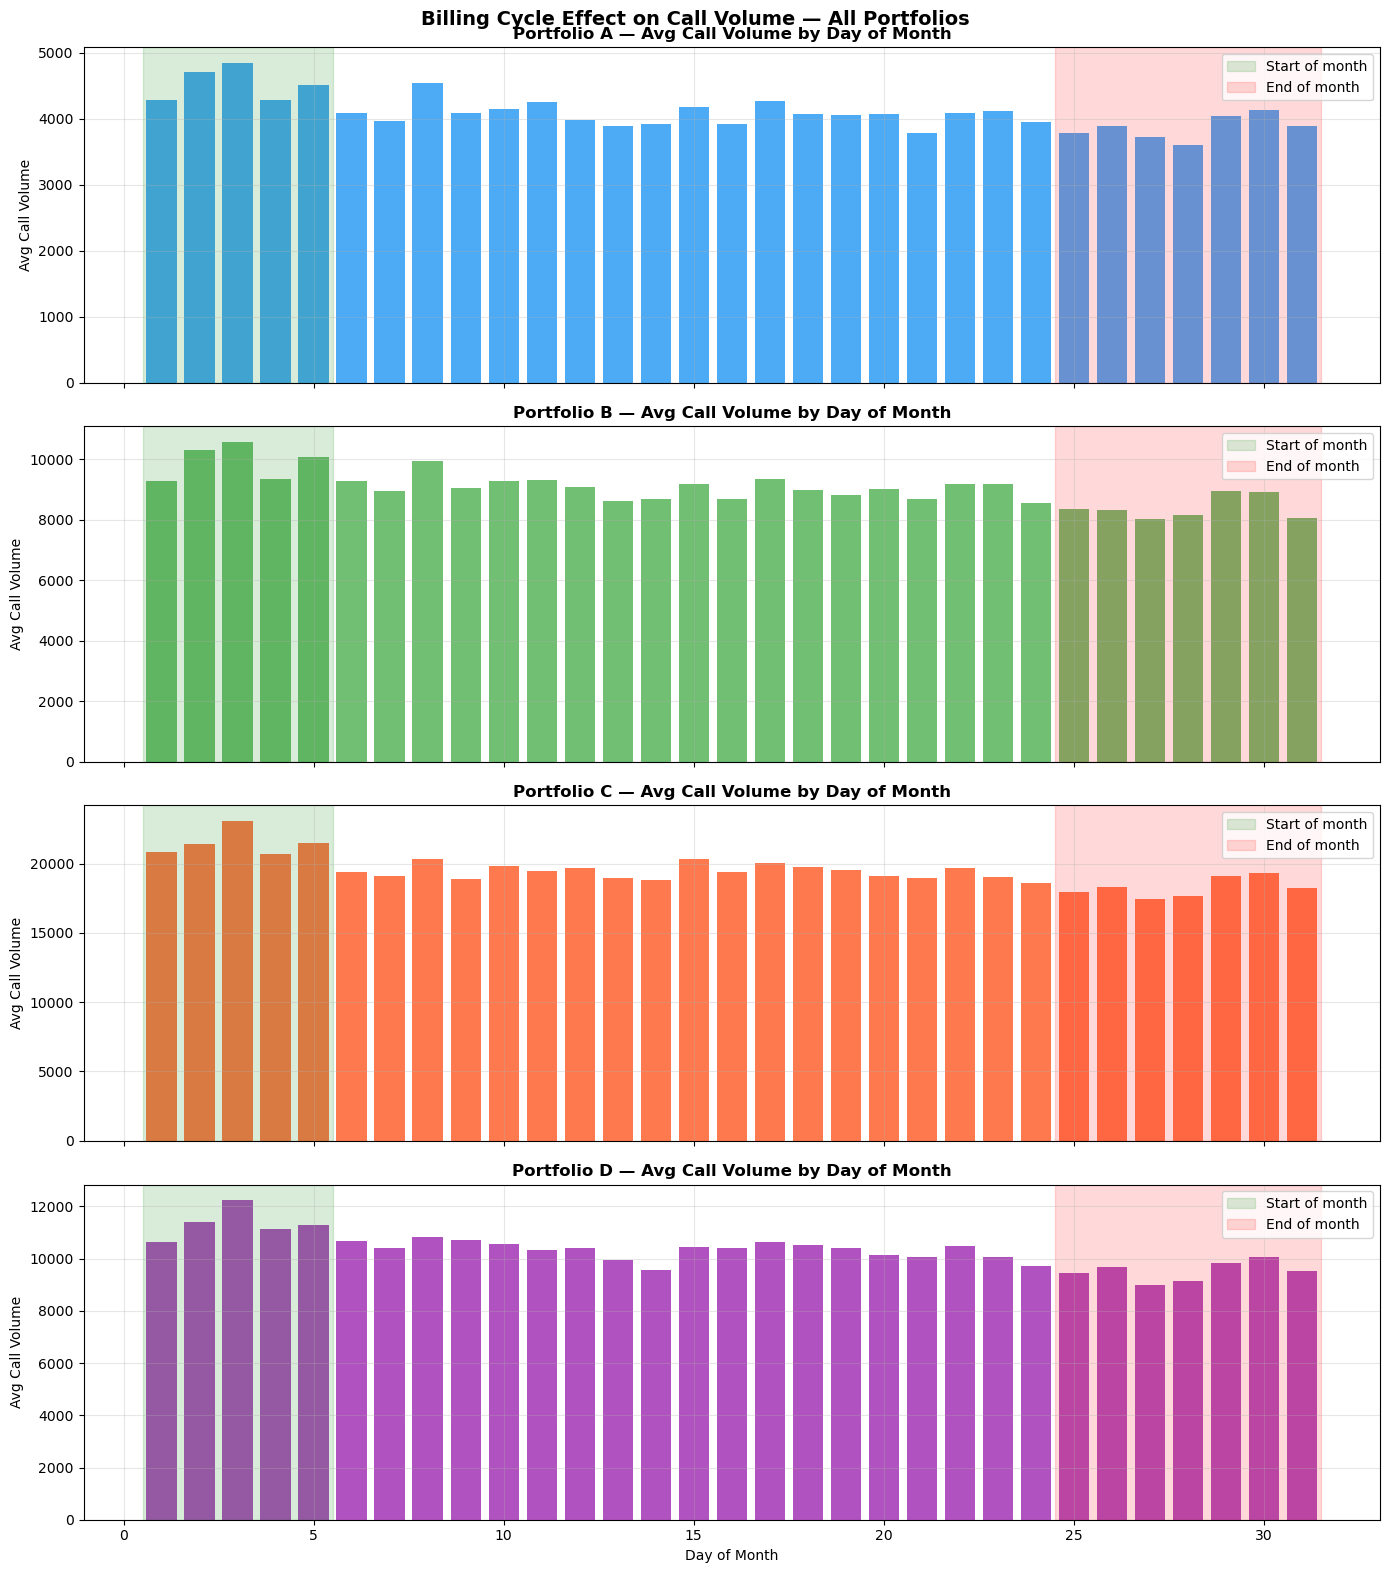

In [14]:
fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

portfolios = ['A', 'B', 'C', 'D']
colors = {'A': '#2196F3', 'B': '#4CAF50', 'C': '#FF5722', 'D': '#9C27B0'}

for i, p in enumerate(portfolios):
    d = pd.read_csv(f'./data/{p} - Daily.csv', index_col=0)
    d['Date'] = pd.to_datetime(d['Date'].str[:8], format='%m/%d/%y')
    d['day_of_month'] = d['Date'].dt.day
    avg_by_dom = d.groupby('day_of_month')['Call Volume'].mean()

    axes[i].bar(avg_by_dom.index, avg_by_dom.values, color=colors[p], alpha=0.8)
    axes[i].axvspan(0.5, 5.5, alpha=0.15, color='green', label='Start of month')
    axes[i].axvspan(24.5, 31.5, alpha=0.15, color='red', label='End of month')
    axes[i].set_title(f'Portfolio {p} — Avg Call Volume by Day of Month', fontweight='bold')
    axes[i].set_ylabel('Avg Call Volume')
    axes[i].legend(loc='upper right')
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Day of Month')
plt.suptitle('Billing Cycle Effect on Call Volume — All Portfolios', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

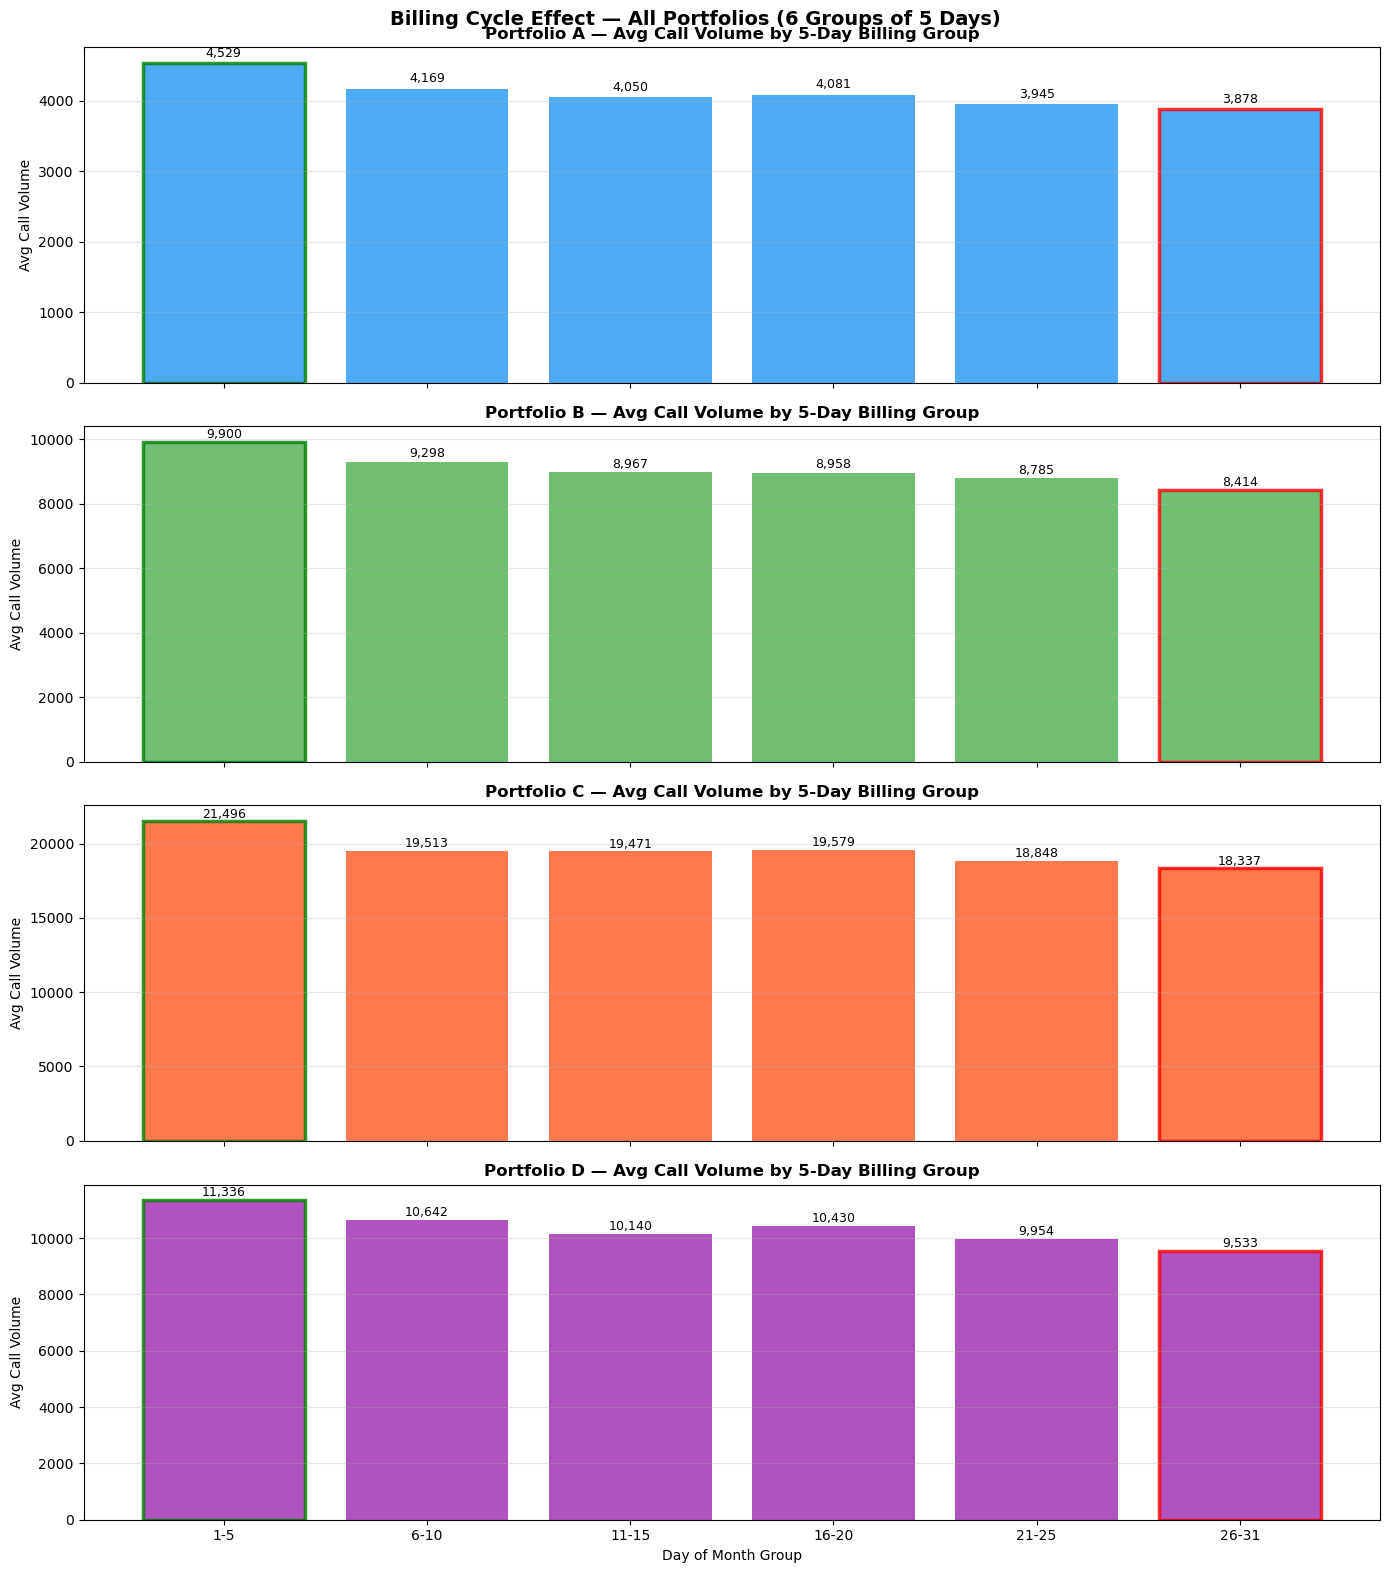

In [15]:
fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

colors = {'A': '#2196F3', 'B': '#4CAF50', 'C': '#FF5722', 'D': '#9C27B0'}

for i, p in enumerate(portfolios):
    d = pd.read_csv(f'./data/{p} - Daily.csv', index_col=0)
    d['Date'] = pd.to_datetime(d['Date'].str[:8], format='%m/%d/%y')
    d['day_of_month'] = d['Date'].dt.day
    
    # Bin into 6 groups of 5 days
    bins = [0, 5, 10, 15, 20, 25, 31]
    labels = ['1-5', '6-10', '11-15', '16-20', '21-25', '26-31']
    d['billing_group'] = pd.cut(d['day_of_month'], bins=bins, labels=labels)
    
    group_avg = d.groupby('billing_group', observed=True)['Call Volume'].mean()
    
    bars = axes[i].bar(group_avg.index, group_avg.values, color=colors[p], alpha=0.8)
    
    # Highlight start and end groups
    bars[0].set_edgecolor('green')
    bars[0].set_linewidth(2.5)
    bars[-1].set_edgecolor('red')
    bars[-1].set_linewidth(2.5)
    
    # Add value labels on top of each bar
    for bar, val in zip(bars, group_avg.values):
        axes[i].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
                     f'{val:,.0f}', ha='center', va='bottom', fontsize=9)
    
    axes[i].set_title(f'Portfolio {p} — Avg Call Volume by 5-Day Billing Group', fontweight='bold')
    axes[i].set_ylabel('Avg Call Volume')
    axes[i].grid(True, alpha=0.3, axis='y')

axes[-1].set_xlabel('Day of Month Group')
plt.suptitle('Billing Cycle Effect — All Portfolios (6 Groups of 5 Days)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

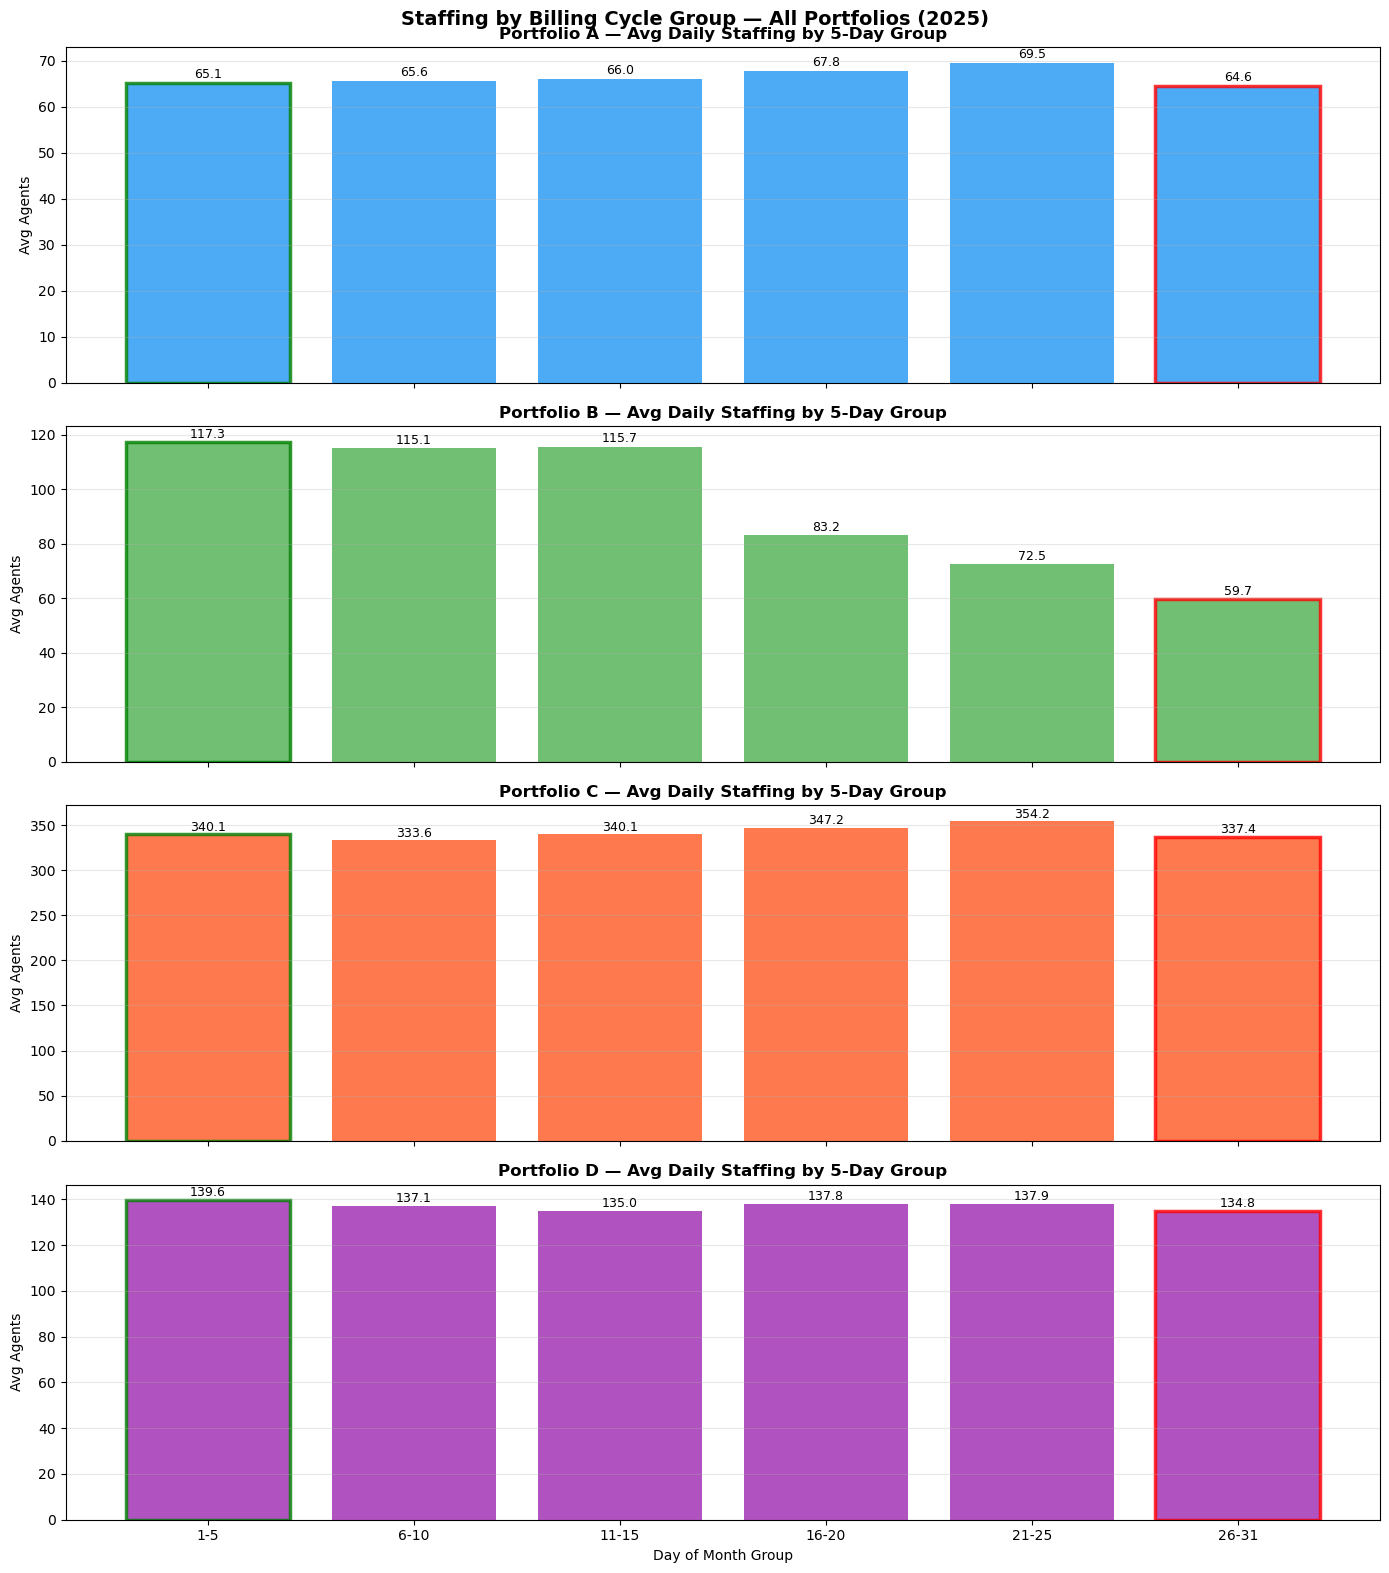

In [17]:
fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

colors = {'A': '#2196F3', 'B': '#4CAF50', 'C': '#FF5722', 'D': '#9C27B0'}

df_staffing = pd.read_csv('./data/Daily Staffing.csv', index_col=0)
df_staffing.columns = ['Date', 'A', 'B', 'C', 'D']
df_staffing['Date'] = pd.to_datetime(df_staffing['Date'])
df_staffing['day_of_month'] = df_staffing['Date'].dt.day

bins   = [0, 5, 10, 15, 20, 25, 31]
labels = ['1-5', '6-10', '11-15', '16-20', '21-25', '26-31']
df_staffing['billing_group'] = pd.cut(df_staffing['day_of_month'], bins=bins, labels=labels)

for i, p in enumerate(['A', 'B', 'C', 'D']):
    group_avg = df_staffing.groupby('billing_group', observed=True)[p].mean()

    bars = axes[i].bar(group_avg.index, group_avg.values, color=colors[p], alpha=0.8)

    bars[0].set_edgecolor('green')
    bars[0].set_linewidth(2.5)
    bars[-1].set_edgecolor('red')
    bars[-1].set_linewidth(2.5)

    for bar, val in zip(bars, group_avg.values):
        axes[i].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                     f'{val:,.1f}', ha='center', va='bottom', fontsize=9)

    axes[i].set_title(f'Portfolio {p} — Avg Daily Staffing by 5-Day Group', fontweight='bold')
    axes[i].set_ylabel('Avg Agents')
    axes[i].grid(True, alpha=0.3, axis='y')

axes[-1].set_xlabel('Day of Month Group')
plt.suptitle('Staffing by Billing Cycle Group — All Portfolios (2025)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

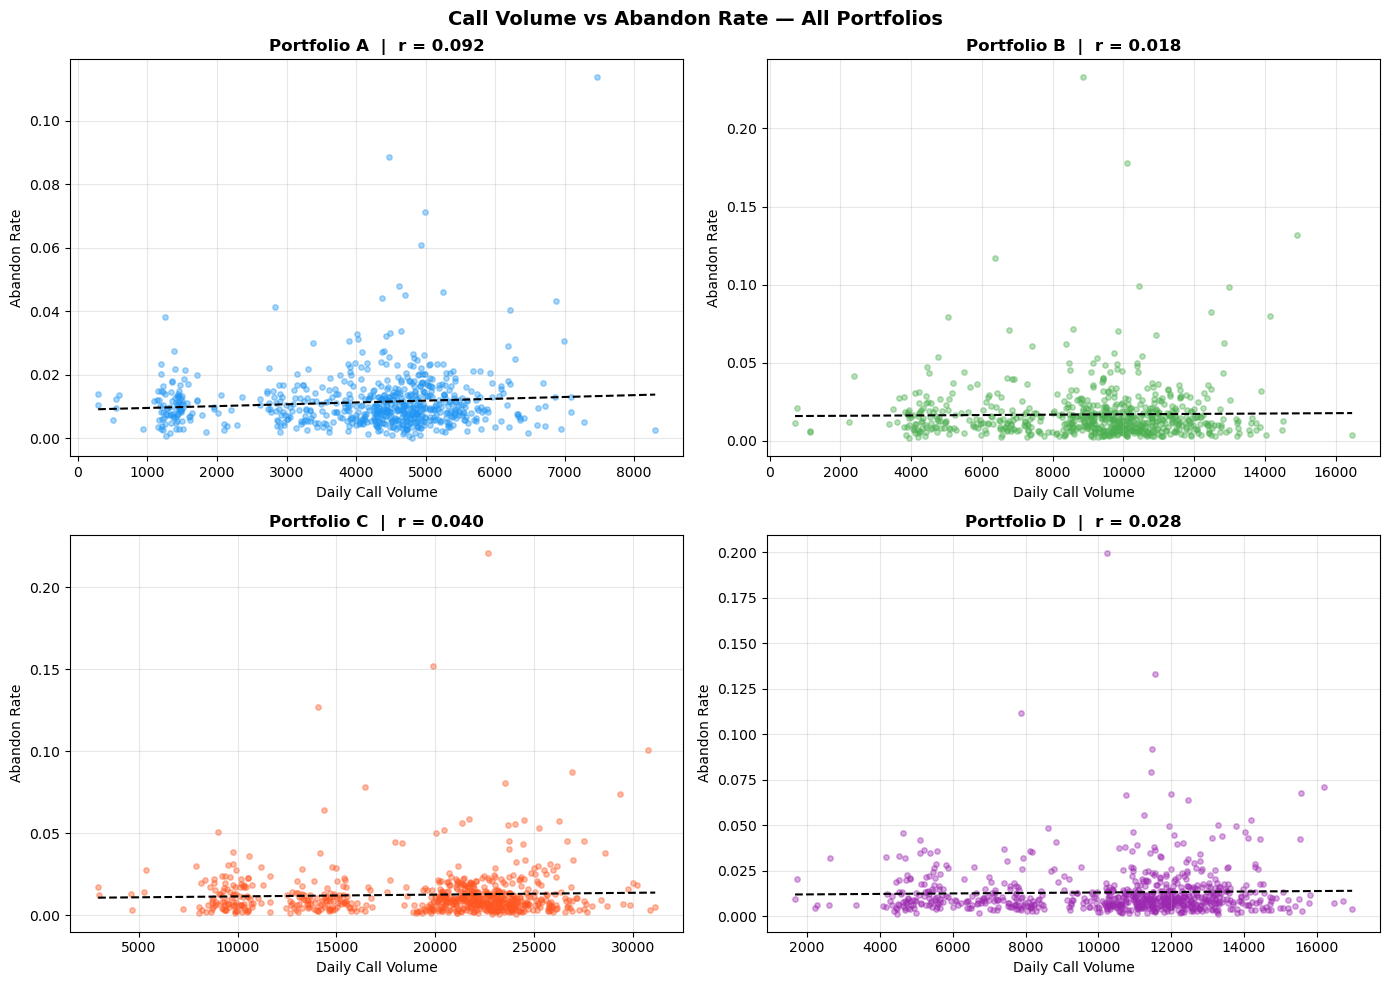

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors = {'A': '#2196F3', 'B': '#4CAF50', 'C': '#FF5722', 'D': '#9C27B0'}

for i, p in enumerate(['A', 'B', 'C', 'D']):
    d = pd.read_csv(f'./data/{p} - Daily.csv', index_col=0)
    d['Date'] = pd.to_datetime(d['Date'].str[:8], format='%m/%d/%y')
    d = d.dropna(subset=['Call Volume', 'Abandon Rate'])

    axes[i].scatter(d['Call Volume'], d['Abandon Rate'], 
                    color=colors[p], alpha=0.4, s=15)

    # Trend line
    z = np.polyfit(d['Call Volume'], d['Abandon Rate'], 1)
    p_line = np.poly1d(z)
    x_sorted = np.sort(d['Call Volume'])
    axes[i].plot(x_sorted, p_line(x_sorted), color='black', linewidth=1.5, linestyle='--')

    corr = d['Call Volume'].corr(d['Abandon Rate'])
    axes[i].set_title(f'Portfolio {p}  |  r = {corr:.3f}', fontweight='bold')
    axes[i].set_xlabel('Daily Call Volume')
    axes[i].set_ylabel('Abandon Rate')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Call Volume vs Abandon Rate — All Portfolios', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
df_interval = pd.read_csv('./data/C - Interval.csv', index_col=0)
df_interval['Date'] = pd.to_datetime(df_interval['Month'] + ' ' + df_interval['Day'].astype(str) + ' 2025')
df_interval['month'] = df_interval['Date'].dt.month

# Build full skeleton first
start = '2025-04-01 00:00:00'
end   = '2025-06-30 23:30:00'
dr    = pd.date_range(start=start, end=end, freq='30min')

df_base = pd.DataFrame({
    'Month':    pd.Series(dr).dt.month_name(),
    'Day':      pd.Series(dr).dt.day,
    'Interval': pd.Series(dr).dt.strftime('%H:%M:%S'),
})

df_interval = df_base.merge(right=df_interval, on=['Month', 'Day', 'Interval'], how='left')

# Interpolate
df_interval['Call Volume']    = df_interval['Call Volume'].interpolate(method='polynomial', order=2).clip(lower=0)
df_interval['CCT']            = df_interval['CCT'].interpolate(method='polynomial', order=2).clip(lower=0)
df_interval['Abandoned Rate'] = df_interval['Abandoned Rate'].interpolate(method='linear').clip(lower=0)

# Rebuild date and time features after skeleton merge
df_interval['Date'] = pd.to_datetime(df_interval['Month'] + ' ' + df_interval['Day'].astype(str) + ' 2025')
df_interval['month'] = df_interval['Date'].dt.month
df_interval['IntervalIdx'] = df_interval['Interval'].apply(
    lambda x: int(x.split(':')[0]) * 2 + int(x.split(':')[1]) // 30
)

print(f"Shape: {df_interval.shape}")
print(f"Nulls remaining:\n{df_interval[['Call Volume','CCT','Abandoned Rate']].isnull().sum()}")

Shape: (4368, 11)
Nulls remaining:
Call Volume       0
CCT               0
Abandoned Rate    0
dtype: int64


In [23]:
df_interval = pd.read_csv('./data/C - Interval.csv', index_col=0)

# Build full skeleton first
start = '2025-04-01 00:00:00'
end   = '2025-06-30 23:30:00'
dr    = pd.date_range(start=start, end=end, freq='30min')

df_base = pd.DataFrame({
    'Month':    pd.Series(dr).dt.month_name(),
    'Day':      pd.Series(dr).dt.day,
    'Interval': pd.Series(dr).dt.strftime('%H:%M:%S'),
})

df_interval = df_base.merge(right=df_interval, on=['Month', 'Day', 'Interval'], how='left')

# Interpolate numeric columns
df_interval['Call Volume']    = df_interval['Call Volume'].interpolate(method='polynomial', order=2).clip(lower=0)
df_interval['CCT']            = df_interval['CCT'].interpolate(method='polynomial', order=2).clip(lower=0)
df_interval['Abandoned Rate'] = df_interval['Abandoned Rate'].interpolate(method='linear').clip(lower=0)

# Rebuild date and time features after skeleton merge
df_interval['Date']        = pd.to_datetime(df_interval['Month'] + ' ' + df_interval['Day'].astype(str) + ' 2025')
df_interval['month']       = df_interval['Date'].dt.month
df_interval['IntervalIdx'] = df_interval['Interval'].apply(
    lambda x: int(str(x).split(':')[0]) * 2 + int(str(x).split(':')[1]) // 30
    if pd.notnull(x) else np.nan
)

print(f"Shape: {df_interval.shape}")
print(f"Nulls remaining:\n{df_interval[['Call Volume','CCT','Abandoned Rate']].isnull().sum()}")

Shape: (4368, 11)
Nulls remaining:
Call Volume       0
CCT               0
Abandoned Rate    0
dtype: int64


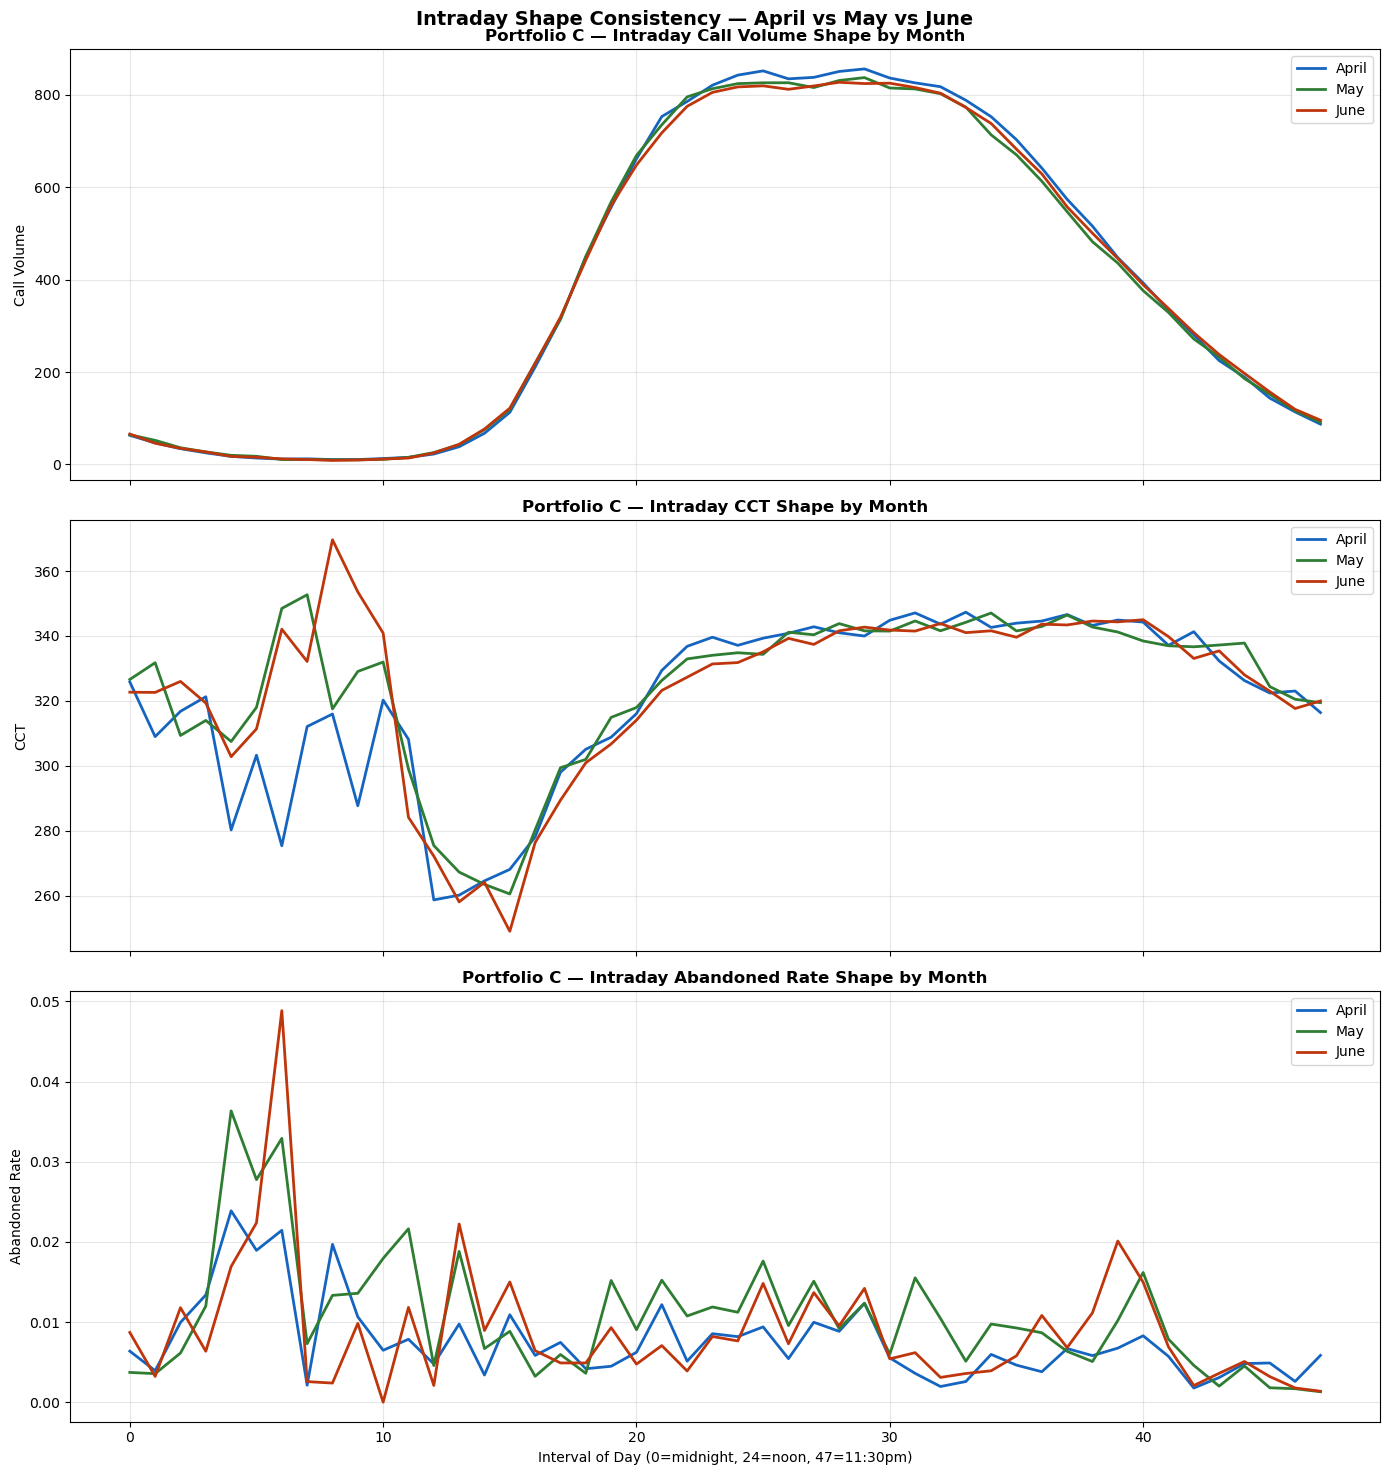

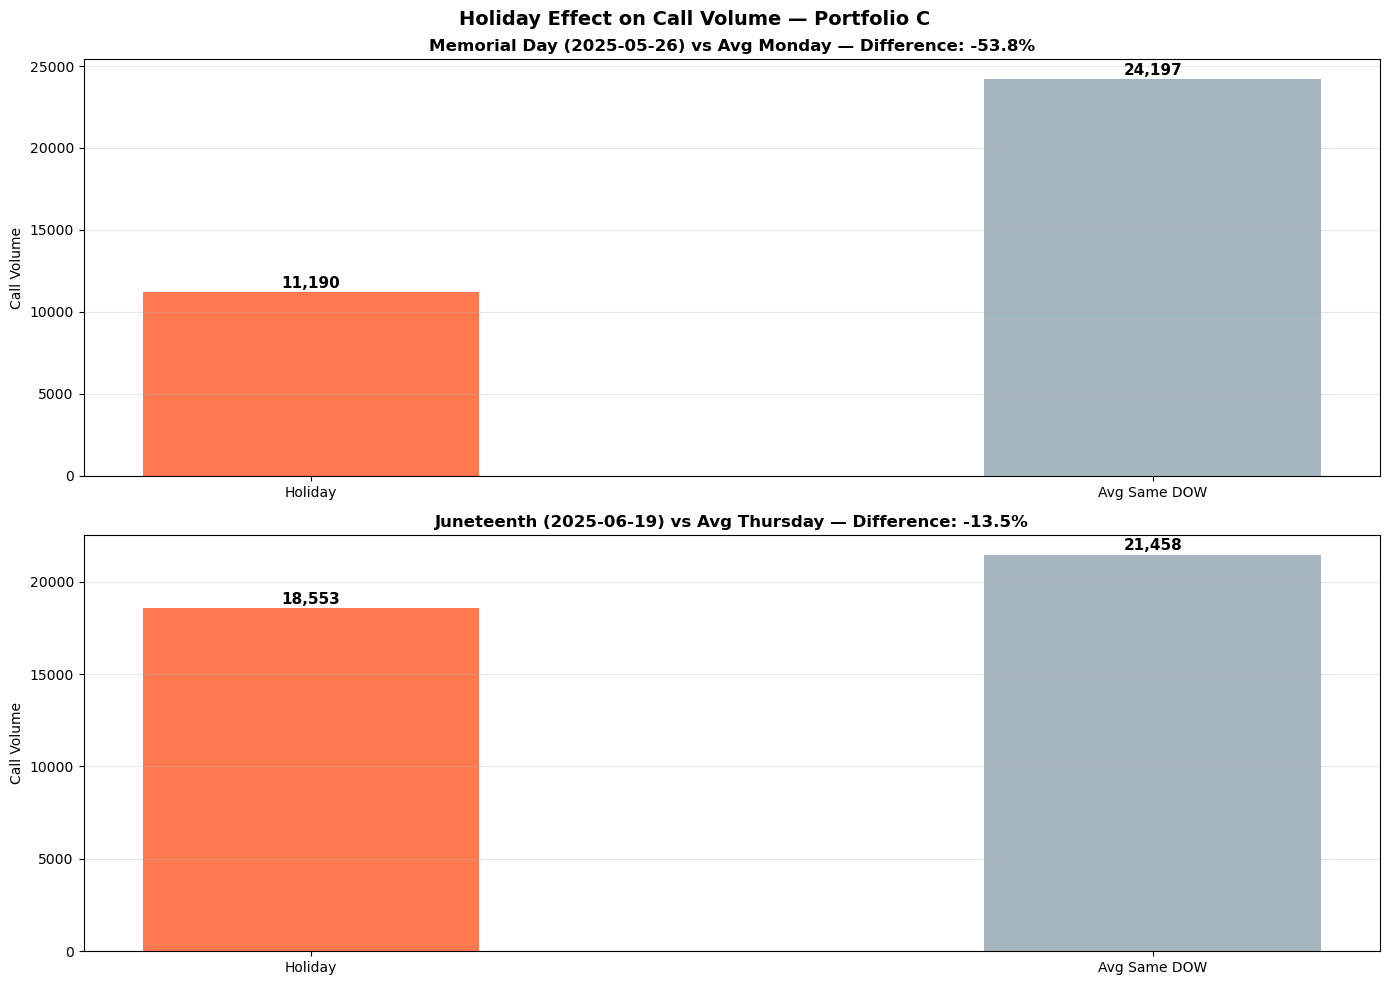

In [24]:
# ── Test 3: Intraday shape consistency across months ──────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 15), sharex=True)

targets = ['Call Volume', 'CCT', 'Abandoned Rate']
colors_month = {4: '#1565C0', 5: '#2E7D32', 6: '#BF360C'}
labels_month = {4: 'April', 5: 'May', 6: 'June'}

for i, target in enumerate(targets):
    for month_num, color in colors_month.items():
        sub = df_interval[df_interval['month'] == month_num]
        avg = sub.groupby('IntervalIdx')[target].mean()
        axes[i].plot(avg.index, avg.values, color=color, linewidth=2,
                     label=labels_month[month_num])
    
    axes[i].set_title(f'Portfolio C — Intraday {target} Shape by Month', fontweight='bold')
    axes[i].set_ylabel(target)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Interval of Day (0=midnight, 24=noon, 47=11:30pm)')
plt.suptitle('Intraday Shape Consistency — April vs May vs June', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Test 4: Holiday effect ────────────────────────────────────────────────────
holidays = {
    '2025-05-26': 'Memorial Day',
    '2025-06-19': 'Juneteenth'
}

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

df_daily_c = pd.read_csv('./data/C - Daily.csv', index_col=0)
df_daily_c['Date'] = pd.to_datetime(df_daily_c['Date'].str[:8], format='%m/%d/%y')
df_daily_c['day_of_week'] = df_daily_c['Date'].dt.dayofweek

for i, (holiday_date, holiday_name) in enumerate(holidays.items()):
    hdate = pd.Timestamp(holiday_date)
    dow   = hdate.dayofweek

    holiday_row = df_daily_c[df_daily_c['Date'] == hdate]
    same_dow    = df_daily_c[
        (df_daily_c['day_of_week'] == dow) &
        (df_daily_c['Date'] != hdate)
    ]

    categories = ['Holiday', 'Avg Same DOW']
    cv_vals    = [
        holiday_row['Call Volume'].values[0],
        same_dow['Call Volume'].mean()
    ]

    bars = axes[i].bar(categories, cv_vals,
                       color=['#FF5722', '#90A4AE'], alpha=0.8, width=0.4)

    for bar, val in zip(bars, cv_vals):
        axes[i].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100,
                     f'{val:,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    pct_diff = (cv_vals[0] - cv_vals[1]) / cv_vals[1] * 100
    axes[i].set_title(f'{holiday_name} ({holiday_date}) vs Avg {hdate.strftime("%A")} — '
                      f'Difference: {pct_diff:+.1f}%', fontweight='bold')
    axes[i].set_ylabel('Call Volume')
    axes[i].grid(True, alpha=0.3, axis='y')

plt.suptitle('Holiday Effect on Call Volume — Portfolio C',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()